In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset och preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score,
confusion_matrix,
ConfusionMatrixDisplay)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Funktioner ifrån metrics.py
from metrics import (
plot_confusion_matrix,
plot_history,
calculate_per_classs_accuracy,
compare_histories)


tf.keras.utils.set_random_seed(42)

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/FER-2013/train",
    validation_split =  0.2,
    subset = "training",
    seed = 42,
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


In [3]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/FER-2013/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=32
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/FER-2013/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32
)

Found 7178 files belonging to 7 classes.


In [5]:
class_names = train_ds.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
train_path = "data/FER-2013/train"
test_path = "data/FER-2013/test"

classes = []
train_counts = []
test_counts = []

for class_name in os.listdir(train_path):

    train_class_path = os.path.join(train_path, class_name)
    test_class_path = os.path.join(test_path, class_name)

    if os.path.isdir(train_class_path):

        train_num = len(os.listdir(train_class_path))
        test_num = len(os.listdir(test_class_path))

        classes.append(class_name)
        train_counts.append(train_num)
        test_counts.append(test_num)

emotion_df = pd.DataFrame({
    "Emotion": classes,
    "Train images": train_counts,
    "Test images": test_counts,
    "Uppdelning": [test/ (train + test) for test, train in zip(test_counts, train_counts)]  
})
emotion_df

,Emotion,Train images,Test images,Uppdelning
0,angry,3995,958,0.193418
1,disgust,436,111,0.202925
2,fear,4097,1024,0.199961
3,happy,7215,1774,0.197352
4,neutral,4965,1233,0.198935
5,sad,4830,1247,0.205200
6,surprise,3171,831,0.207646


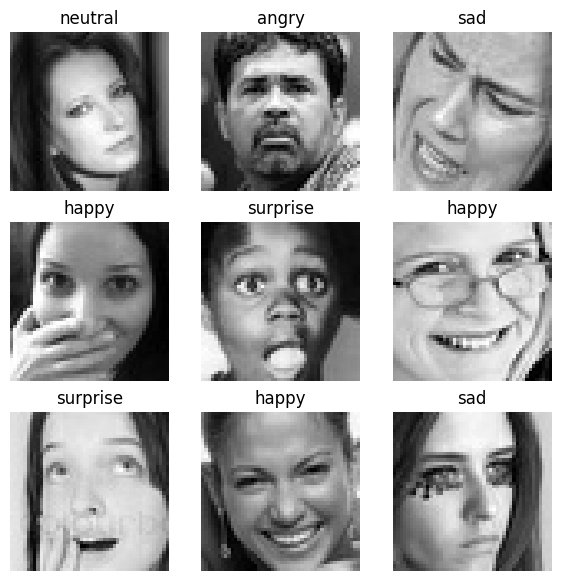

In [7]:
for images, labels in train_ds.take(1):

    plt.figure(figsize=(7,7))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        plt.title(train_ds.class_names[labels[i]])

        plt.axis("off")

In [8]:
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))    
for images, labels in train_ds.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())

0.0
0.9843137


In [9]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

for images, labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)

for images, labels in test_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 48, 48, 1)
(32,)
(32, 48, 48, 1)
(32,)
(32, 48, 48, 1)
(32,)


In [10]:
small_train_ds = train_ds.take(300)
small_val_ds = val_ds.take(20)

## 2

Jag använder alla klasser, annars riskerar vi att modellen lär sig inte vissa emotioner, och det kan skapa klassobalans. Jag begränsar datamängden, för att se om min pipeline funkar somm det ska, och för att upptäcka problem eller buggar snabbare innan jag använder det på större datamängder. Jag kan experimentera lite snabbare och spara tiden.

In [11]:
model = keras.Sequential([
    layers.Input(shape= (48, 48, 1)),

    layers.Conv2D(32,(3,3),activation= "relu"
    ),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(128,(3, 3),activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,263 (876.03 KB)

 Trainable params: 224,263 (876.03 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer = "adam",
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2422 - loss: 1.8379 - val_accuracy: 0.2516 - val_loss: 1.7852
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2735 - loss: 1.7584 - val_accuracy: 0.3141 - val_loss: 1.7100
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3230 - loss: 1.6863 - val_accuracy: 0.3547 - val_loss: 1.6442
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3703 - loss: 1.6093 - val_accuracy: 0.4234 - val_loss: 1.5556
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3965 - loss: 1.5471 - val_accuracy: 0.4016 - val_loss: 1.5542
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4228 - loss: 1.4876 - val_accuracy: 0.4484 - val_loss: 1.4726
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4404 - loss: 1.4589 - val_accuracy: 0.4484 - val_loss: 1.4390
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4543 - loss: 1.4116 - val_accu

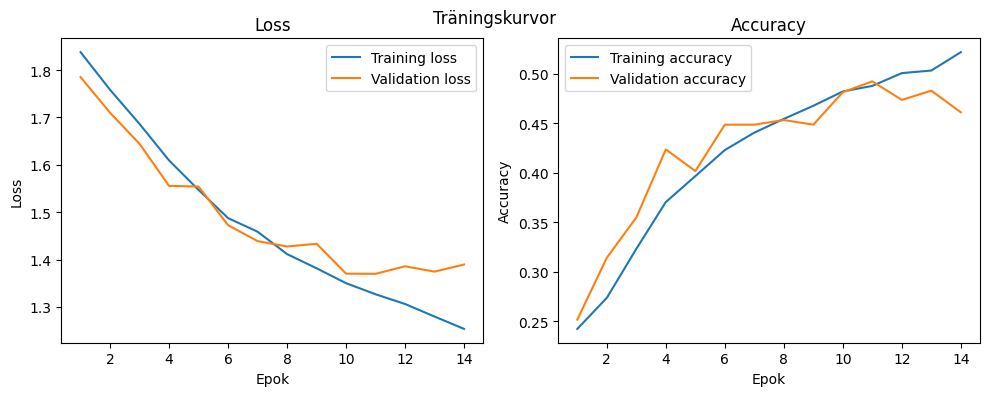

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    monitor="val_loss",
    restore_best_weights=True
)

history_model_1 = model.fit(
    small_train_ds,
    validation_data = small_val_ds,
    epochs = 20,
    batch_size = 64,
    callbacks = [early_stop]
)

plot_history(history_model_1)

In [14]:
print(f"Val accuracy - First Model on small data {history_model_1.history["val_accuracy"][-1]:.4}")

Val accuracy - First Model on small data 0.4609


In [15]:
y_true = []
y_pred = []

for images, labels in small_val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

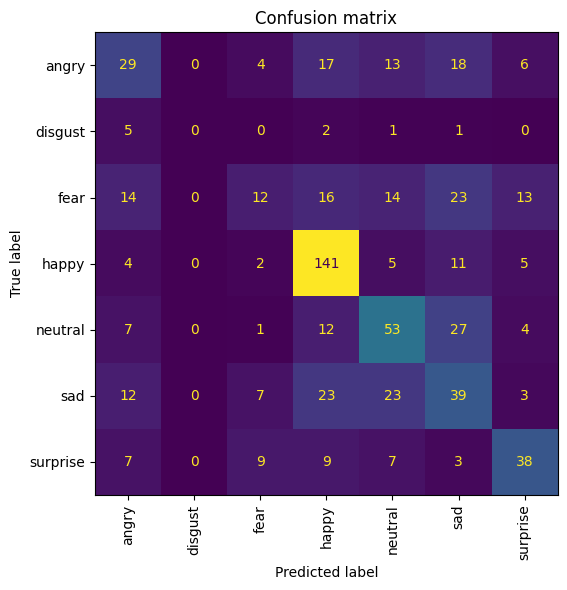

In [16]:
cm_model = plot_confusion_matrix(
    y_true,
    y_pred,
    class_names
)

In [17]:
model_per_class = calculate_per_classs_accuracy(
    cm_model,
    class_names
)
model_per_class

,class_id,class_name,support,correct,accuracy
1,1,disgust,9,0,0.000000
2,2,fear,92,12,0.130435
0,0,angry,87,29,0.333333
5,5,sad,107,39,0.364486
4,4,neutral,104,53,0.509615
6,6,surprise,73,38,0.520548
3,3,happy,168,141,0.839286


In [18]:
better_model = keras.Sequential([

    layers.Conv2D(
        32,(3,3), activation="relu",
        input_shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation= "relu"),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(128,(3, 3),activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

better_model.summary()

c:\Users\janek\OneDrive\Desktop\DL_FER_Jan_Rajt\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,631 (432.15 KB)

 Trainable params: 110,631 (432.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2271 - loss: 1.8488 - val_accuracy: 0.2516 - val_loss: 1.8196
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.2521 - loss: 1.8157 - val_accuracy: 0.2344 - val_loss: 1.8126
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.2585 - loss: 1.8034 - val_accuracy: 0.2438 - val_loss: 1.8006
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.2595 - loss: 1.7931 - val_accuracy: 0.2344 - val_loss: 1.8115
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.2713 - loss: 1.7653 - val_accuracy: 0.2781 - val_loss: 1.7674
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.2941 - loss: 1.7354 - val_accuracy: 0.2734 - val_loss: 1.7448
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.3109 - loss: 1.6882 - val_accuracy: 0.3109 - val_loss: 1.6836
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.3345 - loss: 1.6498 - val_a

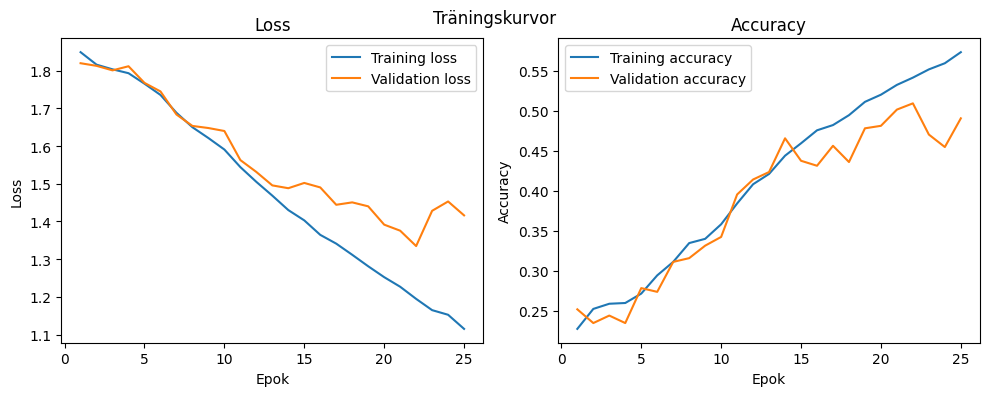

In [19]:
better_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    monitor= "val_loss",
    restore_best_weights=True
)

history_better_model = better_model.fit(
    small_train_ds,
    validation_data = small_val_ds,
    epochs = 30,
    callbacks = [early_stop]
)

plot_history(history_better_model)

In [20]:
print(f"Val accuracy - Better Model on small data {history_better_model.history["val_accuracy"][-1]:.4}")

Val accuracy - Better Model on small data 0.4906


In [21]:
y_true_better = []
y_pred_better = []

for images, labels in small_val_ds:

    predictions = better_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true_better.extend(labels.numpy())
    y_pred_better.extend(predicted_classes)

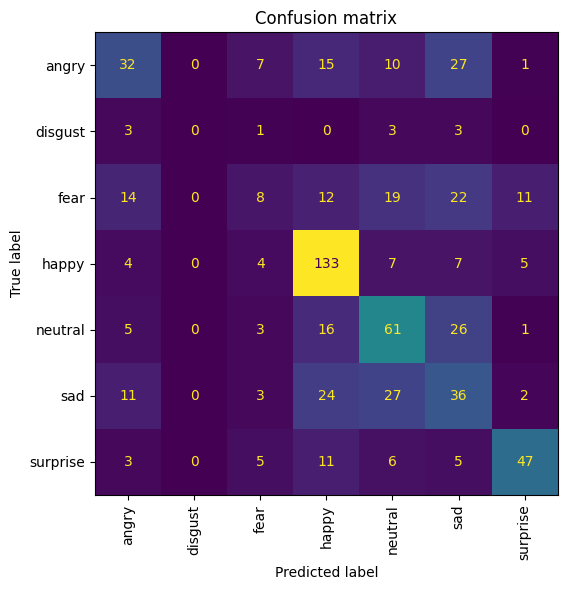

In [22]:
cm_better_model = plot_confusion_matrix(
    y_true_better,
    y_pred_better,
    class_names
)

In [23]:
better_model_per_class = calculate_per_classs_accuracy(
    cm_better_model,
    class_names
)
display(better_model_per_class)

,class_id,class_name,support,correct,accuracy
1,1,disgust,10,0,0.000000
2,2,fear,86,8,0.093023
0,0,angry,92,32,0.347826
5,5,sad,103,36,0.349515
4,4,neutral,112,61,0.544643
6,6,surprise,77,47,0.610390
3,3,happy,160,133,0.831250


## Tolkning för better_model

Den förbättrade modellen uppådde högre accuracy och lägre loss än vår första modell. 

In [24]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

In [25]:
aug_model = keras.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,(3,3), activation="relu",
        input_shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation= "relu"),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(pool_size =(2,2)),

    layers.Conv2D(128,(3, 3),activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])
aug_model.build((None, 48, 48, 1))
aug_model.summary()

c:\Users\janek\OneDrive\Desktop\DL_FER_Jan_Rajt\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,631 (432.15 KB)

 Trainable params: 110,631 (432.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2450 - loss: 1.8349 - val_accuracy: 0.2516 - val_loss: 1.8183
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2573 - loss: 1.8072 - val_accuracy: 0.2391 - val_loss: 1.8240
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2532 - loss: 1.8021 - val_accuracy: 0.2266 - val_loss: 1.8190
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2549 - loss: 1.7970 - val_accuracy: 0.2281 - val_loss: 1.8038
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2541 - loss: 1.7927 - val_accuracy: 0.2422 - val_loss: 1.8003
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2592 - loss: 1.7839 - val_accuracy: 0.2469 - val_loss: 1.7891
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2635 - loss: 1.7770 - val_accuracy: 0.2797 - val_loss: 1.7592
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2726 - loss: 1.7641 - val_accu

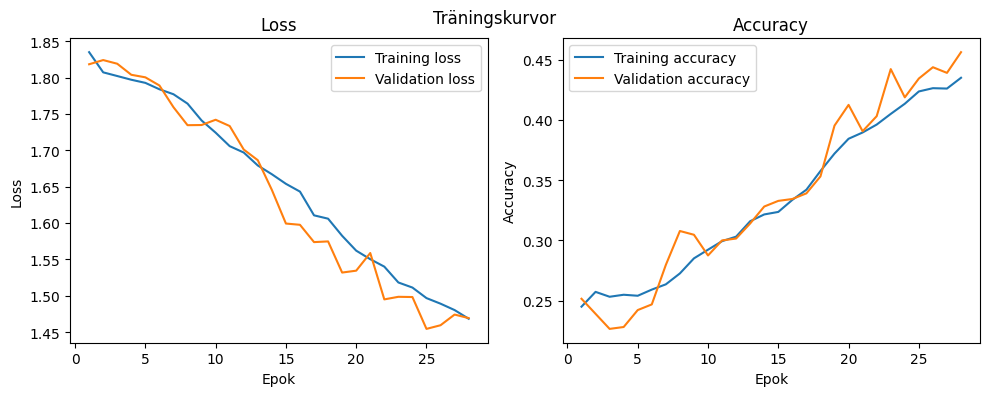

In [26]:
aug_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    monitor= "val_loss",
    restore_best_weights=True
)

history_aug_model = aug_model.fit(
    small_train_ds,
    validation_data = small_val_ds,
    epochs = 30,
    callbacks = [early_stop]
)

plot_history(history_aug_model)

In [27]:
print(f"Val accuracy -  Augmentation Model on small data {history_aug_model.history["val_accuracy"][-1]:.4}")

Val accuracy -  Augmentation Model on small data 0.4563


In [28]:
y_true_aug = []
y_pred_aug = []

for images, labels in small_val_ds:

    predictions = better_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true_aug.extend(labels.numpy())
    y_pred_aug.extend(predicted_classes)

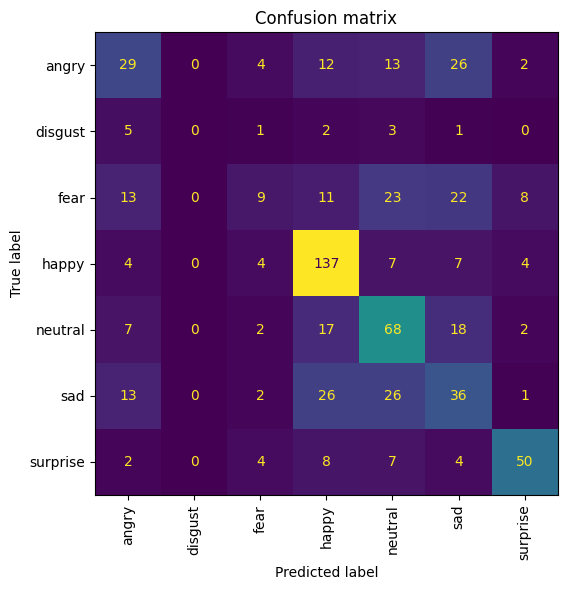

In [29]:
cm_aug_model = plot_confusion_matrix(
    y_true_aug,
    y_pred_aug,
    class_names
)

In [30]:
aug_model_per_class = calculate_per_classs_accuracy(
    cm_aug_model,
    class_names
)
aug_model_per_class

,class_id,class_name,support,correct,accuracy
1,1,disgust,12,0,0.000000
2,2,fear,86,9,0.104651
0,0,angry,86,29,0.337209
5,5,sad,104,36,0.346154
4,4,neutral,114,68,0.596491
6,6,surprise,75,50,0.666667
3,3,happy,163,137,0.840491


## Tolkning

Modellen med data augmenation gav stabilare träningskurvor och mindre tecken på overfitting, men better_model uppnådde bättre accuracy och lägre loss. Confusion matrixen visar också att modellen löste inte problemen med de underpresterande svåra klasser som disgust eller fear.

In [31]:
print(f"Val accuracy - First Model on small data: {history_model_1.history['val_accuracy'][-1]:.4f}")
print(f"Val accuracy - Better Model on small data: {history_better_model.history['val_accuracy'][-1]:.4f}")
print(f"Val accuracy - Aug Model on small data: {history_aug_model.history['val_accuracy'][-1]:.4f}")


print(f"\nVal loss - First Model on small data: {history_model_1.history['val_loss'][-1]:.4f}")
print(f"Val loss - Better Model on small data: {history_better_model.history['val_loss'][-1]:.4f}")
print(f"Val loss - Aug Model on small data: {history_aug_model.history['val_loss'][-1]:.4f}")

comparison_df = pd.concat(

    [
        model_per_class.set_index("class_name")["accuracy"],
        better_model_per_class.set_index("class_name")["accuracy"],
        aug_model_per_class.set_index("class_name")["accuracy"]
    ],

    axis=1
)

comparison_df.columns = [
    "First Model",
    "Better Model",
    "Augmentation Model"
]

display(comparison_df)


Val accuracy - First Model on small data: 0.4609
Val accuracy - Better Model on small data: 0.4906
Val accuracy - Aug Model on small data: 0.4563

Val loss - First Model on small data: 1.3897
Val loss - Better Model on small data: 1.4162
Val loss - Aug Model on small data: 1.4692


,First Model,Better Model,Augmentation Model
class_name,,,
disgust,0.000000,0.000000,0.000000
fear,0.130435,0.093023,0.104651
angry,0.333333,0.347826,0.337209
sad,0.364486,0.349515,0.346154
neutral,0.509615,0.544643,0.596491
surprise,0.520548,0.610390,0.666667
happy,0.839286,0.831250,0.840491


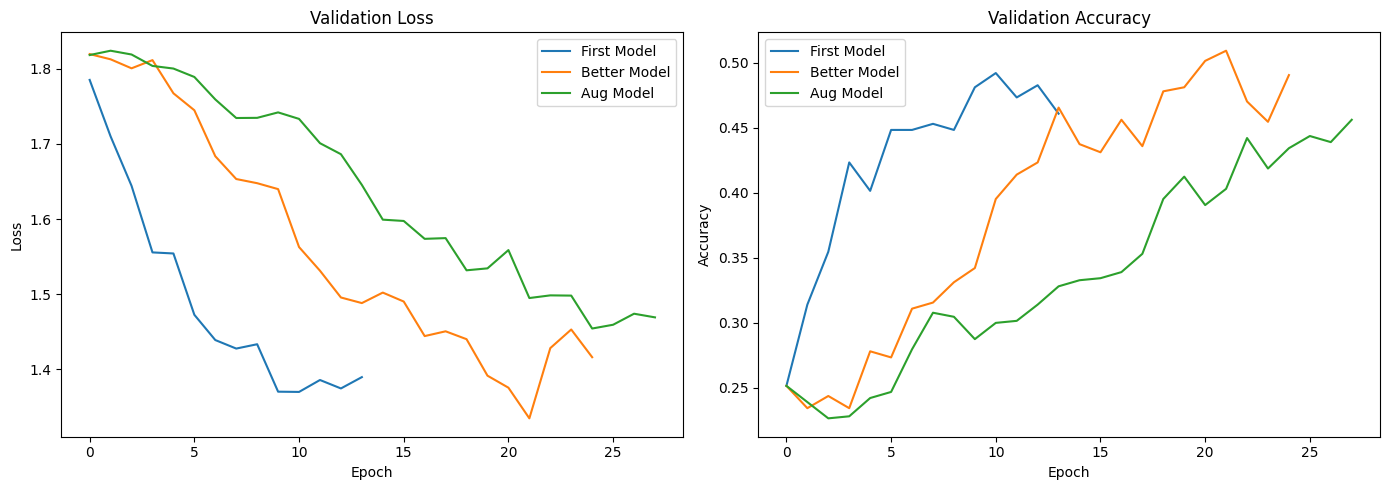

In [32]:
compare_histories(

    [
        history_model_1,
        history_better_model,
        history_aug_model
    ],

    [
        "First Model",
        "Better Model",
        "Aug Model"
    ]
)


## Modelljamförelse

Den förbättrade modellen gav bäst balans mellan validation accuracy och validation loss. Den enklare modellen lärde sig snabbare men verkade plana ut tidigare. Modellen med data augmentation tränade stabilt men uppnådde lägre accuracy, vilket tyder på att augmentation minskade overfitting men inte förbättrade den slutliga prestandan på detta dataset. Alla modeller har svårt med disgust eller fear. 

Resultaten visar att alla modeller hade svårt att klassificera klassen disgust, vilket sannolikt beror på klassobalans och att emotionen är svår att identifiera. Klassen happy gav högst accuracy för samtliga modeller, vilket tyder på att denna emotion har tydligare visuella mönster. Modellen med data augmentation presterade bäst på flera klasser, särskilt surprise och neutral, vilket antyder att augmentation förbättrade generaliseringen för vissa emotioner. Skillnaderna mellan modellerna var dock relativt små, vilket visar att FER-2013 är ett utmanande dataset.

In [33]:
test_loss, test_accuracy = better_model.evaluate(test_ds)

print("Test loss", test_loss)
print("Test accuracy", test_accuracy)


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5109 - loss: 1.2999
Test loss 1.2999125719070435
Test accuracy 0.5108665227890015
